In [ ]:
import pandas as pd
import numpy as np

# Configuración de aleatoriedad para resultados reproducibles
np.random.seed(42)

def generar_dataset_diabetes(n_registros=100):
    # 1. Generar Edad (entre 18 y 80 años)
    edad = np.random.randint(18, 81, size=n_registros)

    # 2. Generar Peso (entre 45kg y 130kg)
    peso = np.random.uniform(45, 130, size=n_registros)

    # 3. Generar Estatura para calcular un IMC coherente
    # (entre 1.50m y 1.95m)
    estatura = np.random.uniform(1.50, 1.95, size=n_registros)

    # 4. Calcular IMC: peso / estatura^2
    imc = peso / (estatura**2)

    # 5. Generar Riesgo (Target)
    # Lógica: A mayor IMC y Edad, mayor probabilidad de riesgo.
    # Usamos una función sigmoide simple con ruido aleatorio.
    probabilidad = 1 / (1 + np.exp(-(0.15 * imc + 0.03 * edad - 6)))
    riesgo = (np.random.random(n_registros) < probabilidad).astype(int)

    # Crear el DataFrame
    df = pd.DataFrame({
        'Edad': edad,
        'Peso_kg': np.round(peso, 1),
        'IMC': np.round(imc, 1),
        'Riesgo_Diabetes': riesgo
    })

    return df

# Generar los datos
dataset = generar_dataset_diabetes(100)

# Mostrar las primeras filas y estadísticas
print("--- Primeros 5 registros ---")
print(dataset.head())
print("\n--- Distribución de Riesgo (0 = No, 1 = Sí) ---")
print(dataset['Riesgo_Diabetes'].value_counts())

# Guardar como CSV por si deseas descargarlo
dataset.to_csv('dataset_diabetes.csv', index=False)

--- Primeros 5 registros ---
   Edad  Peso_kg   IMC  Riesgo_Diabetes
0    56     83.2  25.5                1
1    69     78.6  26.0                1
2    46    123.8  42.8                1
3    32    106.8  34.9                1
4    60     72.8  23.3                0

--- Distribución de Riesgo (0 = No, 1 = Sí) ---
Riesgo_Diabetes
1    55
0    45
Name: count, dtype: int64


In [ ]:
from google.colab import data_table
data_table.DataTable(dataset, include_index=False, num_rows_per_page=10)

,Edad,Peso_kg,IMC,Riesgo_Diabetes
0,56,83.2,25.5,1
1,69,78.6,26.0,1
2,46,123.8,42.8,1
3,32,106.8,34.9,1
4,60,72.8,23.3,0
...,...,...,...,...
95,71,128.0,41.9,1
96,46,79.9,25.9,1
97,80,47.8,12.7,1
98,35,74.3,31.6,0


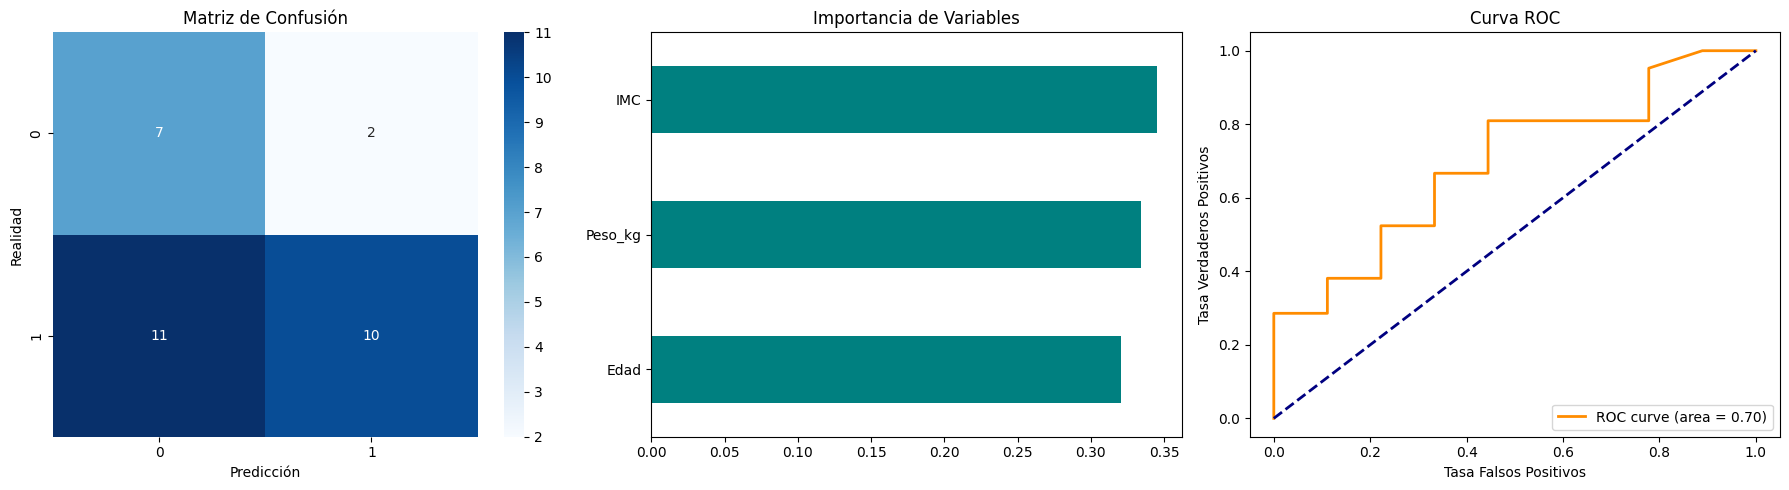

In [ ]:
from sklearn.model_selection import train_test_split

# Seleccionamos las variables características (Features) y el objetivo (Target)
X = dataset[['Edad', 'Peso_kg', 'IMC']]
y = dataset['Riesgo_Diabetes']

# Dividimos: 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 80
Muestras de prueba: 20


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Inicializamos los modelos
modelos = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

# Entrenamos cada uno en un bucle
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    print(f"Modelo {nombre} entrenado con éxito.")

Modelo Logistic Regression entrenado con éxito.
Modelo Decision Tree entrenado con éxito.
Modelo Random Forest entrenado con éxito.
Modelo SVM entrenado con éxito.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

resultados = {}

for nombre, modelo in modelos.items():
    predicciones = modelo.predict(X_test)
    acc = accuracy_score(y_test, predicciones)
    resultados[nombre] = acc
    print(f"\n--- Reporte: {nombre} ---")
    print(classification_report(y_test, predicciones))

# Comparativa rápida de Accuracy
print("\nComparativa de Exactitud:")
for m, a in resultados.items():
    print(f"{m}: {a:.2f}")


--- Reporte: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.29      0.80      0.42         5
           1       0.83      0.33      0.48        15

    accuracy                           0.45        20
   macro avg       0.56      0.57      0.45        20
weighted avg       0.70      0.45      0.46        20


--- Reporte: Decision Tree ---
              precision    recall  f1-score   support

           0       0.38      0.60      0.46         5
           1       0.83      0.67      0.74        15

    accuracy                           0.65        20
   macro avg       0.60      0.63      0.60        20
weighted avg       0.72      0.65      0.67        20


--- Reporte: Random Forest ---
              precision    recall  f1-score   support

           0       0.25      0.60      0.35         5
           1       0.75      0.40      0.52        15

    accuracy                           0.45        20
   macro avg       0.50   